In [1]:
import networkx as nx
import numpy as np
from collections import defaultdict
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import torch
from torch_geometric.utils import from_scipy_sparse_matrix
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch.optim import Adam
from sklearn.metrics import roc_auc_score

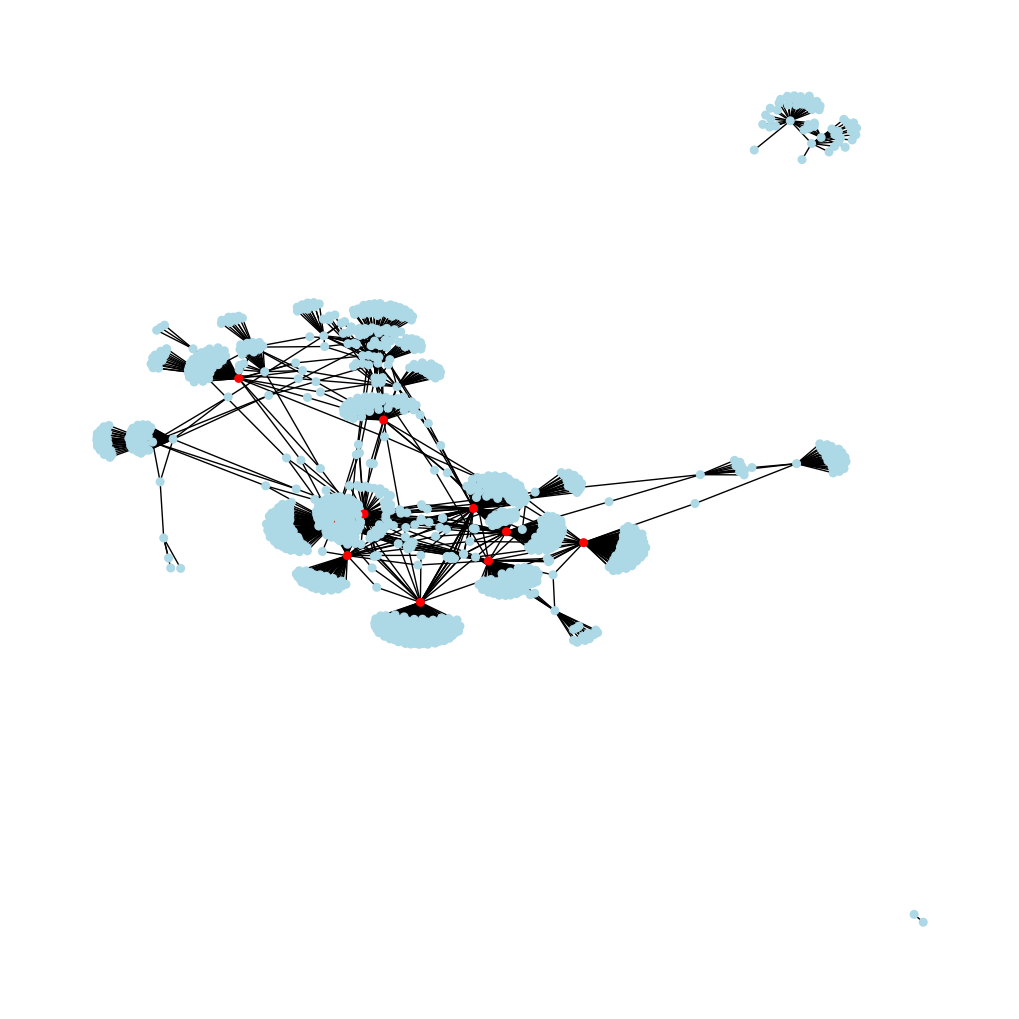

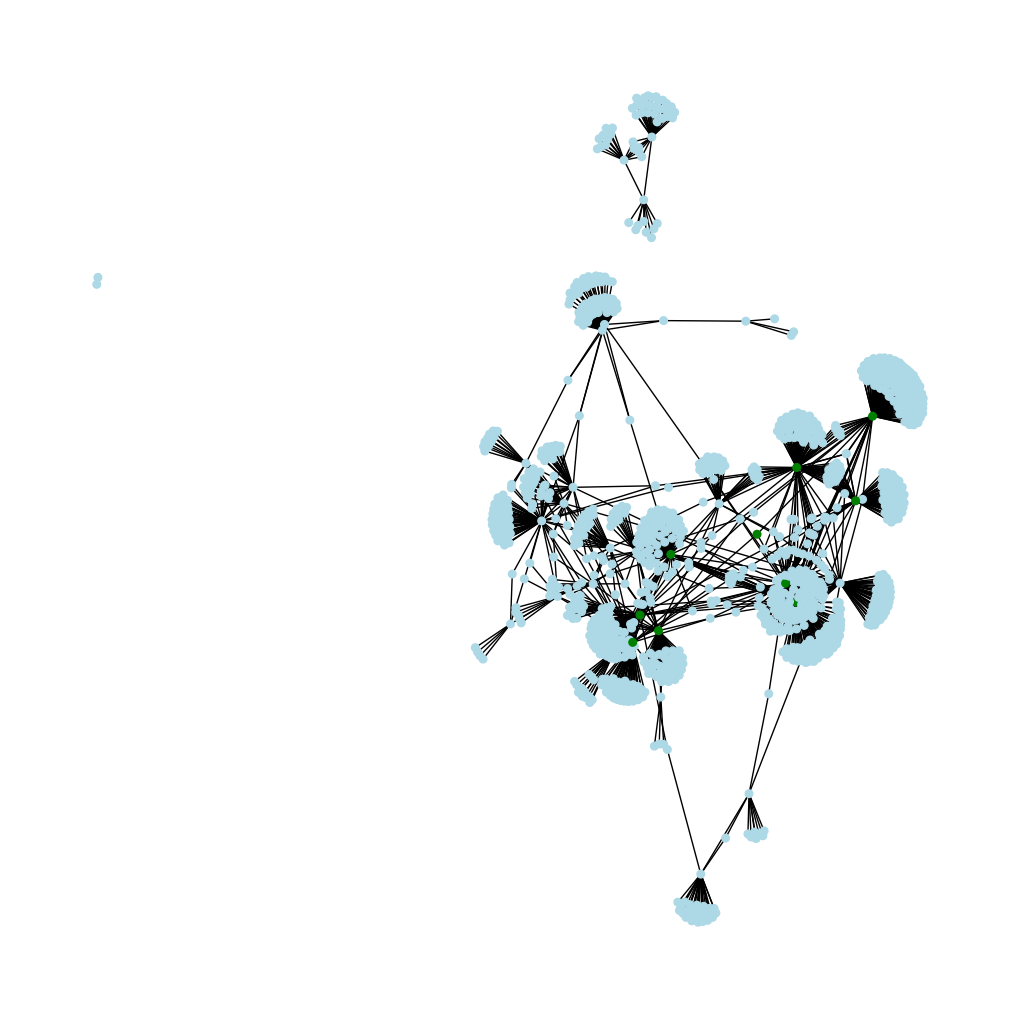

In [5]:
# Ex. 1
# 1. In the first exercise you will implement a version of the OddBall algorithm discussed in the course.
# You will first load the dataset from the ca-AstroPh.txt file (each line contains an edge of the graph)
# and build the corresponding undirected graph using networkx.Graph. Each appearance of an edge in the
# dataset will increase the weight of the edge by one (you can store the weight for each edge with a key
# using G[node1][node2][”weight”] = weight).
# 2. Extract the four features from the egonet (subgraph consisting of all neighbours) corresponding to
# each node:
#    • Ni - number of neighbors
#    • Ei - number of edges in egonet i
#    • Wi - total weight of egonet i
#    • λw, i - principal eigenvalue of the weighted adjacency matrix of egonet i
# Store the features in the Graph object using nx.set node attributes
# 3. Compute the anomaly score for each node by fitting a LinearRegression model (from sklearn.linear model)
# with the logarithmic scale of the 2 features (Ei and Ni - which should detect near-cliques and stars). The
# anomaly score will be: scorei = max(yi, Cxiθ)/min(yi, Cxiθ) * log(|yi − Cxiθ | + 1)
# given the power-law equation y = Cxθ
# 4. Sort the scores of the nodes in descending order and draw the graph using nx.draw(). Using the node color
# parameter for the specified function, draw the nodes corresponding to the biggest 10 scores with a different
# color. Use just the first 1500 rows from the file when generating the graph.
# 5. Modify the anomaly score as the sum of the normalized score that was computed earlier and the score
# obtained by LOF (for the pair of Ei and Ni features) and draw again the graph using a different color for
# the nodes corresponding to the biggest 10 scores.
import warnings
warnings.filterwarnings("ignore")

# loading data and building weighted undirected graph
G = nx.Graph()

with open("ca-AstroPh.txt", "r") as f:
    for i, line in enumerate(f):
        if i >= 1500:
            break
        u, v = map(int, line.strip().split())
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
        else:
            G.add_edge(u, v, weight=1)


# extracting egonet features for each node
Ni = {}
Ei = {}
Wi = {}
Lambda_w = {}

for node in G.nodes():
    ego = nx.ego_graph(G, node, radius=1)

    # Ni: number of neighbors (excluding the node itself)
    Ni[node] = ego.number_of_nodes() - 1

    # Ei: number of edges in egonet
    Ei[node] = ego.number_of_edges()

    # Wi: total weight in egonet
    Wi[node] = sum(d["weight"] for _, _, d in ego.edges(data=True))

    # λw: principal eigenvalue
    if ego.number_of_nodes() > 1:
        A = nx.to_numpy_array(ego, weight="weight")
        eigvals = np.linalg.eigh(A)[0]
        Lambda_w[node] = np.max(eigvals)
    else:
        Lambda_w[node] = 0.0

# storing the features in the graph
nx.set_node_attributes(G, Ni, "Ni")
nx.set_node_attributes(G, Ei, "Ei")
nx.set_node_attributes(G, Wi, "Wi")
nx.set_node_attributes(G, Lambda_w, "Lambda_w")

X = []
y = []
nodes = []

for node in G.nodes():
    if Ni[node] > 0 and Ei[node] > 0:
        X.append(np.log(Ni[node]))
        y.append(np.log(Ei[node]))
        nodes.append(node)

X = np.array(X).reshape(-1, 1)
y = np.array(y)

# fitting a LinearRegression model
lr = LinearRegression()
lr.fit(X, y)

theta = lr.coef_[0]
C = np.exp(lr.intercept_)

# computing OddBall score
scores = {}

for node in nodes:
    x = Ni[node]
    y_real = Ei[node]
    y_pred = C * (x ** theta)

    score = (max(y_real, y_pred) / min(y_real, y_pred)) * \
            np.log(abs(y_real - y_pred) + 1)

    scores[node] = score

top10 = sorted(scores, key=scores.get, reverse=True)[:10]

colors = []
for node in G.nodes():
    if node in top10:
        colors.append("red")
    else:
        colors.append("lightblue")

plt.figure(figsize=(10, 10))
nx.draw(G, node_color=colors, node_size=30, with_labels=False)
plt.show()

# computing LOF on (Ei, Ni)
X_lof = np.array([[Ei[n], Ni[n]] for n in nodes])

lof = LocalOutlierFactor(n_neighbors=50)
lof.fit(X_lof)
lof_scores = -lof.negative_outlier_factor_

# normalizing LOF scores
lof_scores = (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())

# normalizing OddBall scores
oddball_vals = np.array([scores[n] for n in nodes])
oddball_norm = (oddball_vals - oddball_vals.min()) / \
               (oddball_vals.max() - oddball_vals.min())

final_scores = {}
for i, node in enumerate(nodes):
    final_scores[node] = oddball_norm[i] + lof_scores[i]

top10_final = sorted(final_scores, key=final_scores.get, reverse=True)[:10]

colors = []
for node in G.nodes():
    if node in top10_final:
        colors.append("green")
    else:
        colors.append("lightblue")

plt.figure(figsize=(10, 10))
nx.draw(G, node_color=colors, node_size=30, with_labels=False)
plt.show()

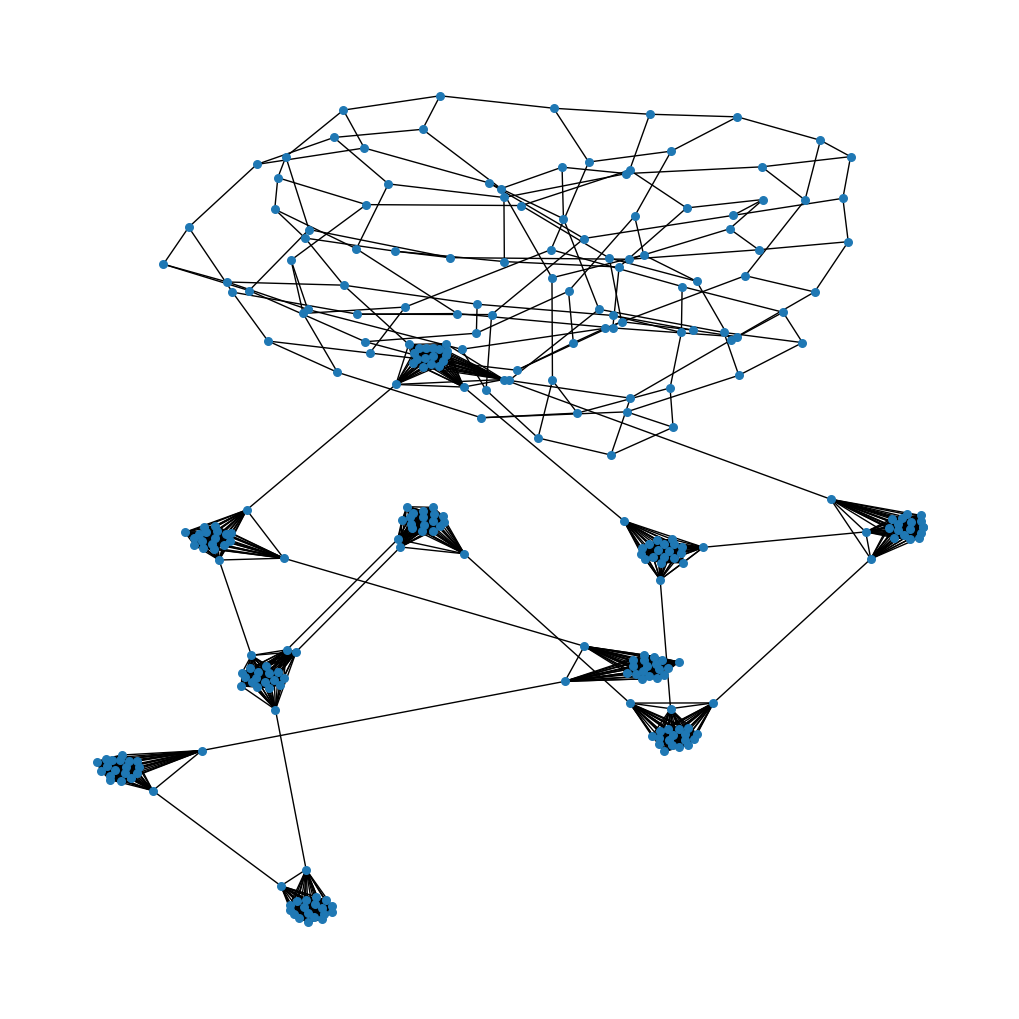

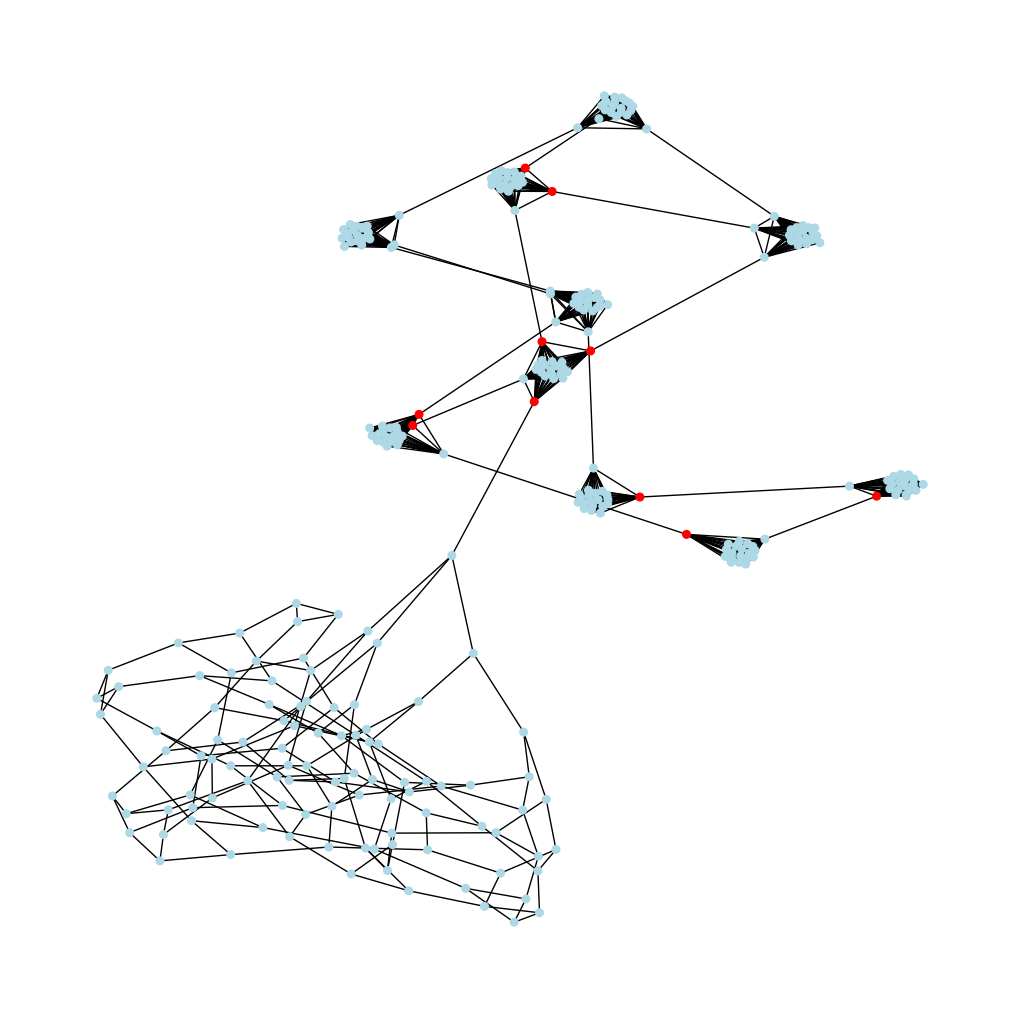

In [6]:
# Ex. 2
# 1. In this exercise we will generate some types of graph anomalies using networkx package. You will first
# generate a regular graph with 100 nodes where each one will have a degree 3 using networkx.random regular
# graph. You will merge it with another graph that will contain 10 cliques with 20 nodes each. This one will
# be generated using networkx.connected caveman graph(). Both will be merged using networkx.union() and some
# random edges will be added in order to build a connected graph. Draw the resulted graph. Use the model
# developed in the first exercise to detect the first 10 nodes that are most probably part of a clique in the
# final merged graph (using Ei and Ni) and draw them using a different color.

# using networkx.random_regular_graph to generate a regular graph with 100 nodes, each one with a degree 3 
G1 = nx.random_regular_graph(d=3, n=100)

# using networkx.connected_caveman_graph() to generate a graph that will contain 10 cliques with 20 nodes each
G2 = nx.connected_caveman_graph(l=10, k=20)

# merging using networkx.union()
G = nx.union(G1, G2, rename=("R_", "C_"))

# adding random edges
nodes = list(G.nodes())

while not nx.is_connected(G):
    u, v = np.random.choice(nodes, 2, replace=False)
    G.add_edge(u, v, weight=1)

for u, v in G.edges():
    if "weight" not in G[u][v]:
        G[u][v]["weight"] = 1

# drawing the resulted graph
plt.figure(figsize=(10, 10))
nx.draw(G, node_size=30, with_labels=False)
plt.show()

Ni = {}
Ei = {}

for node in G.nodes():
    ego = nx.ego_graph(G, node)
    Ni[node] = ego.number_of_nodes() - 1
    Ei[node] = ego.number_of_edges()

X = []
y = []
nodes = []

for n in G.nodes():
    if Ni[n] > 0 and Ei[n] > 0:
        X.append(np.log(Ni[n]))
        y.append(np.log(Ei[n]))
        nodes.append(n)

X = np.array(X).reshape(-1, 1)
y = np.array(y)

lr = LinearRegression()
lr.fit(X, y)

theta = lr.coef_[0]
C = np.exp(lr.intercept_)

scores = {}

for n in nodes:
    y_pred = C * (Ni[n] ** theta)
    scores[n] = (max(Ei[n], y_pred) / min(Ei[n], y_pred)) * \
                np.log(abs(Ei[n] - y_pred) + 1)

top10 = sorted(scores, key=scores.get, reverse=True)[:10]

colors = ["red" if n in top10 else "lightblue" for n in G.nodes()]

plt.figure(figsize=(10, 10))
nx.draw(G, node_color=colors, node_size=30, with_labels=False)
plt.show()

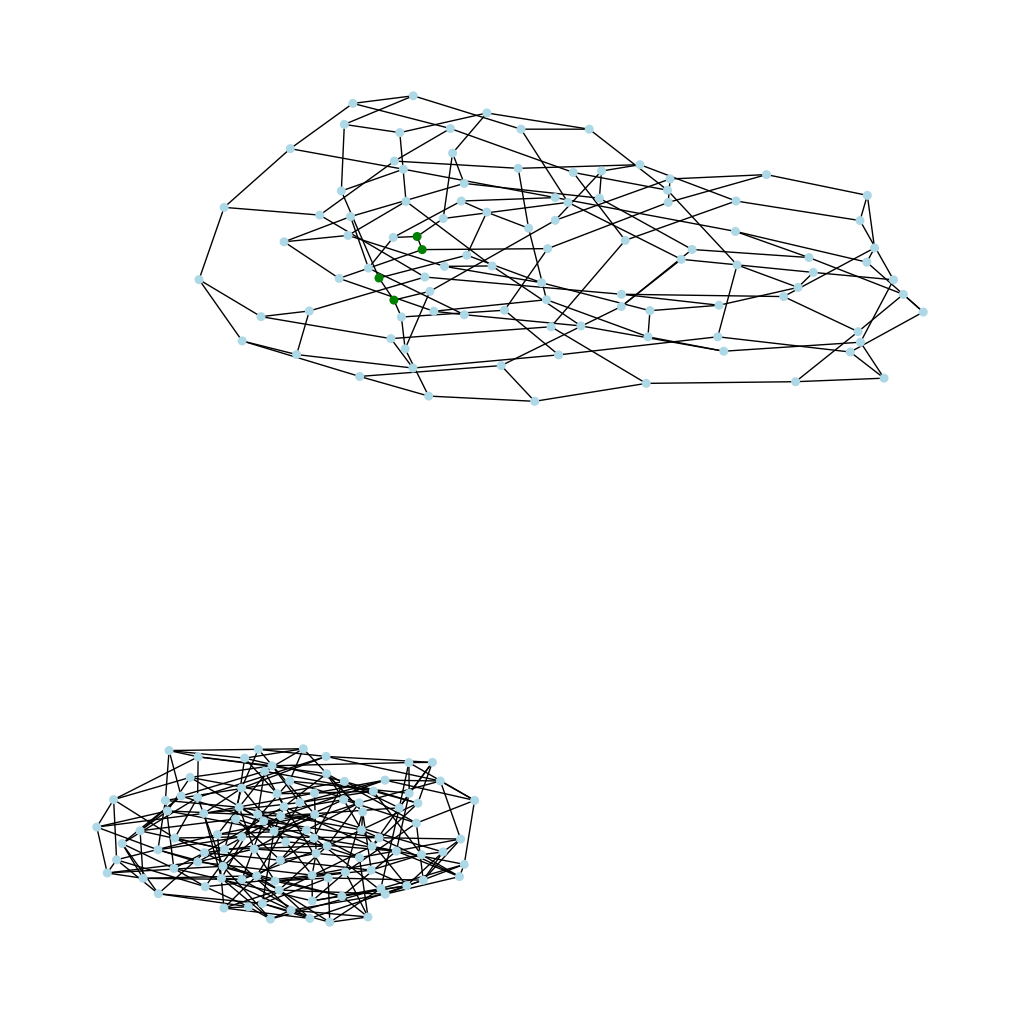

In [7]:
# 2. Here you will generate some HeavyVicinity anomalies. You will generate a regular graph with 100 nodes
# where each one will have a degree 3 and another one that has 100 nodes and each member node has degree 5
# (using networkx.random regular graph). You will merge them using networkx.union() and then you will assign
# weight 1 for each edge using G.add edge(edge[0], edge[1], weight=1) while iterating over all the edges. You
# will pick 2 random nodes and you will add 10 to the weights of all the edges from their egonets
# (using G[node1][node2][”weight”]+= 10). Then you will use the same model to draw with a different color the
# 4 nodes that have the greatest score (using Wi and Ei - which should detect the heavy vicinities).

# generating a regular graph with 100 nodes where each one has a degree 3
G1 = nx.random_regular_graph(3, 100)

# generating a regular graph that has 100 nodes and each member node has degree 5
G2 = nx.random_regular_graph(5, 100)

# merging using networkx.union()
G = nx.union(G1, G2, rename=("A_", "B_"))

# assigning weight 1 for each edge
for u, v in G.edges():
    G[u][v]["weight"] = 1

# picking 2 random nodes and adding 10 to the weights of all the edges from their egonets
heavy_nodes = np.random.choice(list(G.nodes()), 2, replace=False)

for n in heavy_nodes:
    ego = nx.ego_graph(G, n)
    for u, v in ego.edges():
        G[u][v]["weight"] += 10

Wi = {}
Ei = {}

for n in G.nodes():
    ego = nx.ego_graph(G, n)
    Ei[n] = ego.number_of_edges()
    Wi[n] = sum(d["weight"] for _, _, d in ego.edges(data=True))

X = []
y = []
nodes = []

for n in G.nodes():
    if Ei[n] > 0 and Wi[n] > 0:
        X.append(np.log(Ei[n]))
        y.append(np.log(Wi[n]))
        nodes.append(n)

X = np.array(X).reshape(-1, 1)
y = np.array(y)

lr = LinearRegression()
lr.fit(X, y)

theta = lr.coef_[0]
C = np.exp(lr.intercept_)

scores = {}

for n in nodes:
    y_pred = C * (Ei[n] ** theta)
    scores[n] = (max(Wi[n], y_pred) / min(Wi[n], y_pred)) * \
                np.log(abs(Wi[n] - y_pred) + 1)

top4 = sorted(scores, key=scores.get, reverse=True)[:4]

colors = ["green" if n in top4 else "lightblue" for n in G.nodes()]

plt.figure(figsize=(10, 10))
nx.draw(G, node_color=colors, node_size=30, with_labels=False)
plt.show()

In [ ]:
# Ex. 3
# 1. In this exercise we will design a Graph Autoencoder (GAE) capable of ranking anomalous nodes from an 
# Attributed Graph (based on reconstruction error). For this, we will use GCNConv layers from torch
# geometric.nn. The autoencoder will contain an Encoder that will encode both structure information and
# node attributes, and two separate decoders. One will reconstruct the attributes of the nodes from the
# latent representations of the encoder and the other one will reconstruct the adjacency matrix (from the
# same latent representations).
# 2. Load the ACM dataset (from ACM.mat file) and extract the attributes of the nodes (”Attributes” key),
# the adjacency matrix (”Network” key) and the labels of the nodes (”Label” key). You can convert the
# adjacency matrix from the sparse matrix format in edge list using from scipy sparse matrix() function
# from torch geometric.utils.convert
# 3. Design a graph autoencoder that subclasses the torch.nn.Model class. This will contain the encoder
# and the two decoder sub-models (these will also subclass torch.nn.Model). The encoder will contain:
#   • 1 GCNConv layer which encodes the input samples in samples of size 128, followed by a relu activation
#   • 1 GCNConv layer which encodes the output of the previous layer to 64-sized samples, followed by a
# relu activation
# The attribute decoder will consist of the same 2 layers (but with reversed input/output size). The
# structure decoder will contain one GCNConv layer (that will keep the dimension of the latent
# representations), followed by a relu activation. Then, the structure decoder will return the Z@ZT
# product (where Z is the output of the relu activation) in order to match the size of the adjacency
# matrix. You have to define the forward method for each of the 3 models (in order to define the computations
# performed when data is passed through the network).
# 4. You have to define the following custom loss function that takes as input the original attributes of
# the nodes - X, the reconstructed ones - Xˆ, the original adjacency matrix - A, the reconstructed one - Aˆ
# and the α parameter which balances the importance of attribute and structure reconstruction (for alpha you
# will use a value of 0.8): L = α∥X − Xˆ∥2F + (1 − α)∥A − Aˆ∥2F
# 5. You have to define your training procedure. First you will define your optimizer (Adam, with a learning
# rate of 0.004) and then you will perform the necessary computations for each epoch:
#    • reset the gradients using optimizer.zero grad()
#    • pass data through the autoencoder and get the reconstructions for attributes and adjacency matrix
#    • compute the loss
#    • compute the gradients using backward() method
#    • update the network weights using optimizer.step()
#    • at every 5 epochs compute the ROC AUC score for the data based on the scores represented by the
# reconstruction errors

import scipy.io
# loading ACM.mat
data = scipy.io.loadmat('ACM.mt')

X_sparse = data['Attributes']
X = torch.tensor(X_sparse.toarray(), dtype=torch.float)

A_sparse = data['Network']
y = torch.tensor(data['Label'].flatten(), dtype=torch.long)

# converting adjacency to edge index
edge_index, _ = from_scipy_sparse_matrix(A_sparse)


# Encoder
class Encoder(nn.Module):
    def __init__(self, in_channels, hidden1=128, hidden2=64):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden1)
        self.conv2 = GCNConv(hidden1, hidden2)
        
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        z = F.relu(self.conv2(x, edge_index))
        return z


# Attribute Decoder
class AttrDecoder(nn.Module):
    def __init__(self, latent_dim, hidden1=128, out_channels=None):
        super().__init__()
        self.conv1 = GCNConv(latent_dim, hidden1)
        self.conv2 = GCNConv(hidden1, out_channels)
        
    def forward(self, z, edge_index):
        x_hat = F.relu(self.conv1(z, edge_index))
        x_hat = self.conv2(x_hat, edge_index)
        return x_hat


# Structure Decoder
class StructDecoder(nn.Module):
    def __init__(self, latent_dim, block_size=512):
        super().__init__()
        self.conv = GCNConv(latent_dim, latent_dim)
        self.block_size = block_size

    def forward(self, z, edge_index):
        z = F.relu(self.conv(z, edge_index))

        N = z.size(0)
        A_hat = torch.zeros(N, N, device=z.device)

        for i in range(0, N, self.block_size):
            z_i = z[i:i+self.block_size]
            A_hat[i:i+self.block_size] = torch.matmul(z_i, z.t())

        return A_hat


# Graph Autoencoder
class GAE(nn.Module):
    def __init__(self, in_channels, hidden1, hidden2):
        super().__init__()
        self.encoder = Encoder(in_channels, hidden1, hidden2)
        self.attr_decoder = AttrDecoder(hidden2, hidden1, in_channels)
        self.struct_decoder = StructDecoder(hidden2)
        
    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        x_hat = self.attr_decoder(z, edge_index)
        A_hat = self.struct_decoder(z, edge_index)
        return x_hat, A_hat


def custom_loss(X, X_hat, A_sparse, A_hat, alpha=0.8):
    attr_loss = F.mse_loss(X_hat, X)

    A_dense = torch.tensor(
        A_sparse.toarray(),
        dtype=A_hat.dtype,
        device=A_hat.device
    )

    struct_loss = F.mse_loss(A_hat.detach(), A_dense)

    return alpha * attr_loss + (1 - alpha) * struct_loss


# model
in_channels = X.shape[1]
model = GAE(in_channels, hidden1=128, hidden2=64)
optimizer = Adam(model.parameters(), lr=0.004)

# training
epochs = 50
alpha = 0.8

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    if epoch == 1:
        print("Starting training...")

    X_hat, A_hat = model(X, edge_index)

    loss = custom_loss(X, X_hat, A_sparse, A_hat, alpha)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        attr_error = torch.norm(X - X_hat, dim=1)
        struct_error = torch.norm(A_dense - A_hat, dim=1)
        scores = alpha * attr_error + (1 - alpha) * struct_error

        roc_auc = roc_auc_score(y.numpy(), scores.detach().numpy())
        print(f"Epoch {epoch:02d} | Loss: {loss.item():.4f} | ROC AUC: {roc_auc:.4f}")